# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

17 campaigns that occurred between May 2008 and November 2010, corresponding to a total of 79354 contacts.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



1. Basic Missing Data Information:
Total missing values: 0
Missing values per column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64
Missing values percentage per column:
age               0.0
job               0.0
marital           0.0
education         0.0
default           0.0
housing           0.0
loan              0.0
contact           0.0
month             0.0
day_of_week       0.0
duration          0.0
campaign          0.0
pdays             0.0
previous          0.0
poutcome          0.0
emp.var.rate      0.0
cons.price.idx    0.0
cons.conf.idx     0.0
euribor3m         0.0
nr.employed       0.0
y  

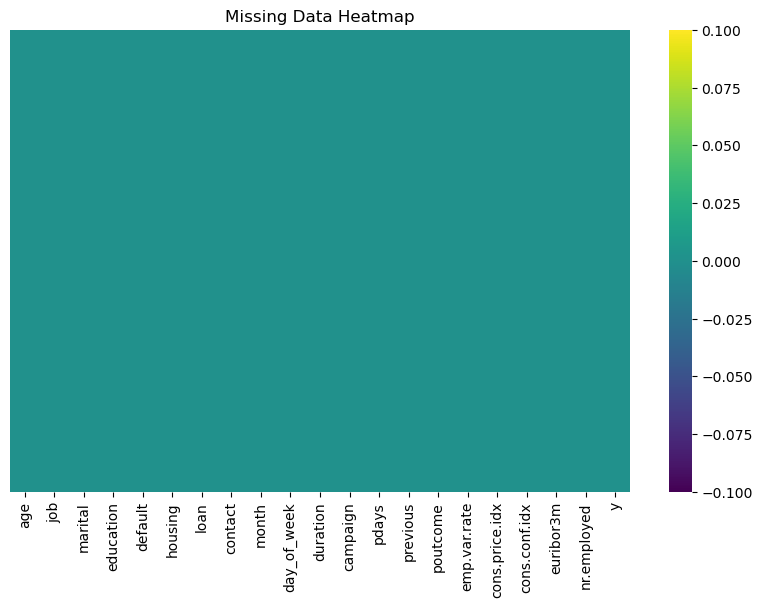


5. Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Check for missing values - basic methods
print("1. Basic Missing Data Information:")
print(f"Total missing values: {df.isnull().sum().sum()}")
print(f"Missing values per column:\n{df.isnull().sum()}")
print(f"Missing values percentage per column:\n{(df.isnull().sum() / len(df)) * 100}")

# 2. More detailed missing data analysis
print("\n2. Detailed Missing Data Analysis:")
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100,
    'Data_Type': df.dtypes
})
print(missing_data)

# 3. Check for rows with any missing values
print(f"\n3. Rows with missing values: {df.isnull().any(axis=1).sum()}")
print(f"Rows without missing values: {df.notnull().all(axis=1).sum()}")

# 4. Visualize missing data pattern
print("\n4. Missing Data Visualization:")
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

# 5. Get info about the dataset
print("\n5. Dataset Info:")
print(df.info())

No data were found to be missing. The summary of the data above shows that the only changes that need to be made is code the categorical columns for processing. Encoded columns include: job, marital, education, default, housing, loan, contact, month, day_of_week, poutcome, y

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

Business Objective: To determine which client characteristics, behaviors, and campaign factors most strongly influence whether a customer subscribes to a long‑term deposit, enabling the bank to improve marketing effectiveness, target the right customers, reduce campaign costs, and increase conversion rates.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [8]:
# Identify categorical columns (dtype = object)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Save the encoded dataset
df_encoded.to_csv('bank_additional_encoded.csv', index=False)

# Display results
print('Categorical columns encoded:')
print(cat_cols)

print('\nEncoded DataFrame info:')
df_encoded.info()


Categorical columns encoded:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

Encoded DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 54 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            41188 non-null  int64  
 1   duration                       41188 non-null  int64  
 2   campaign                       41188 non-null  int64  
 3   pdays                          41188 non-null  int64  
 4   previous                       41188 non-null  int64  
 5   emp.var.rate                   41188 non-null  float64
 6   cons.price.idx                 41188 non-null  float64
 7   cons.conf.idx                  41188 non-null  float64
 8   euribor3m                      41188 non-null  float64
 9   nr.employed                    41188 non-null  float64
 10

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [9]:
from sklearn.model_selection import train_test_split

# Load the encoded dataset
df_encoded = pd.read_csv('bank_additional_encoded.csv')

# Separate features and target
X = df_encoded.drop('y_yes', axis=1)  # y_yes is the encoded target column
y = df_encoded['y_yes']

# Train-test split (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (32950, 53)
Test set shape: (8238, 53)


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [10]:
# Extract the target column
y = df_encoded['y_yes']

# Calculate percentages
percentage = y.value_counts(normalize=True) * 100

print("Percentage of y_yes = 0:", percentage[0])
print("Percentage of y_yes = 1:", percentage[1])


Percentage of y_yes = 0: 88.73458288821988
Percentage of y_yes = 1: 11.265417111780131


/tmp/ipykernel_2014/1948384918.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Percentage of y_yes = 0:", percentage[0])
/tmp/ipykernel_2014/1948384918.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Percentage of y_yes = 1:", percentage[1])


As shown above, the data set is imbalanced since the majority (88.7 percent) of all people do not sign up for a long-term deposit account. Our classifier should perform better than 88.7 accuracy, but accuracy is not a good metric for imbalanced data. We should also look at the classifiers precision, and recall.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize logistic regression
log_reg = LogisticRegression(max_iter=1000)

# Train the model
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)



/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Problem 9: Score the Model

What is the accuracy of your model?

In [15]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# Print evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)

Accuracy: 0.9146637533381888
Precision: 0.7019748653500898
Recall: 0.4213362068965517
F1 Score: 0.5265993265993266
Confusion Matrix:
 [[7144  166]
 [ 537  391]]


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [16]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC


models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'DecisionTree': DecisionTreeClassifier(),
    'SVM': SVC()
}

results = []

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - start
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    results.append({'Model': name, 'Accuracy': accuracy, 'Fit_Time': fit_time})

results_df = pd.DataFrame(results)
print(results_df)


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn

                Model  Accuracy   Fit_Time
0  LogisticRegression  0.914664   2.519418
1                 KNN  0.907502   0.077343
2        DecisionTree  0.891114   0.267401
3                 SVM  0.898034  18.491719


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [ ]:

# Define models and hyperparameter grids
models_params = {
    'LogisticRegression': (
        LogisticRegression(max_iter=1000),
        {'C': [0.01, 0.1, 1, 10]} ),
    
    'KNN': (
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 7, 9]}  ),
    
    'DecisionTree': (
        DecisionTreeClassifier(),
        {'max_depth': [3, 5, 10, None]} ),
   
    'SVM': (
        SVC(),
        {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']} )}

results = []

# Grid Search using F1 score
for name, (model, params) in models_params.items():
    grid = GridSearchCV(model, params, scoring='f1', cv=3)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Best_Params': grid.best_params_,
        'F1_Score': f1
    })

results_df = pd.DataFrame(results)
print(results_df)


Based on the F score, the model is the Decision Tree with a max depth of three. 

                Model                    Best_Params  F1_Score
0  LogisticRegression                     {'C': 0.1}  0.516961
1                 KNN             {'n_neighbors': 9}  0.553321
2        DecisionTree               {'max_depth': 3}  0.605960
3                 SVM  {'C': 10, 'kernel': 'linear'}  0.43921

In [19]:
# Decision Tree with max depth = 3
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

# Predictions
y_pred = dt.predict(X_test)

# Analytics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)


Accuracy: 0.9133284777858703
Precision: 0.6210407239819005
Recall: 0.5915948275862069
F1 Score: 0.6059602649006622
Confusion Matrix:
 [[6975  335]
 [ 379  549]]


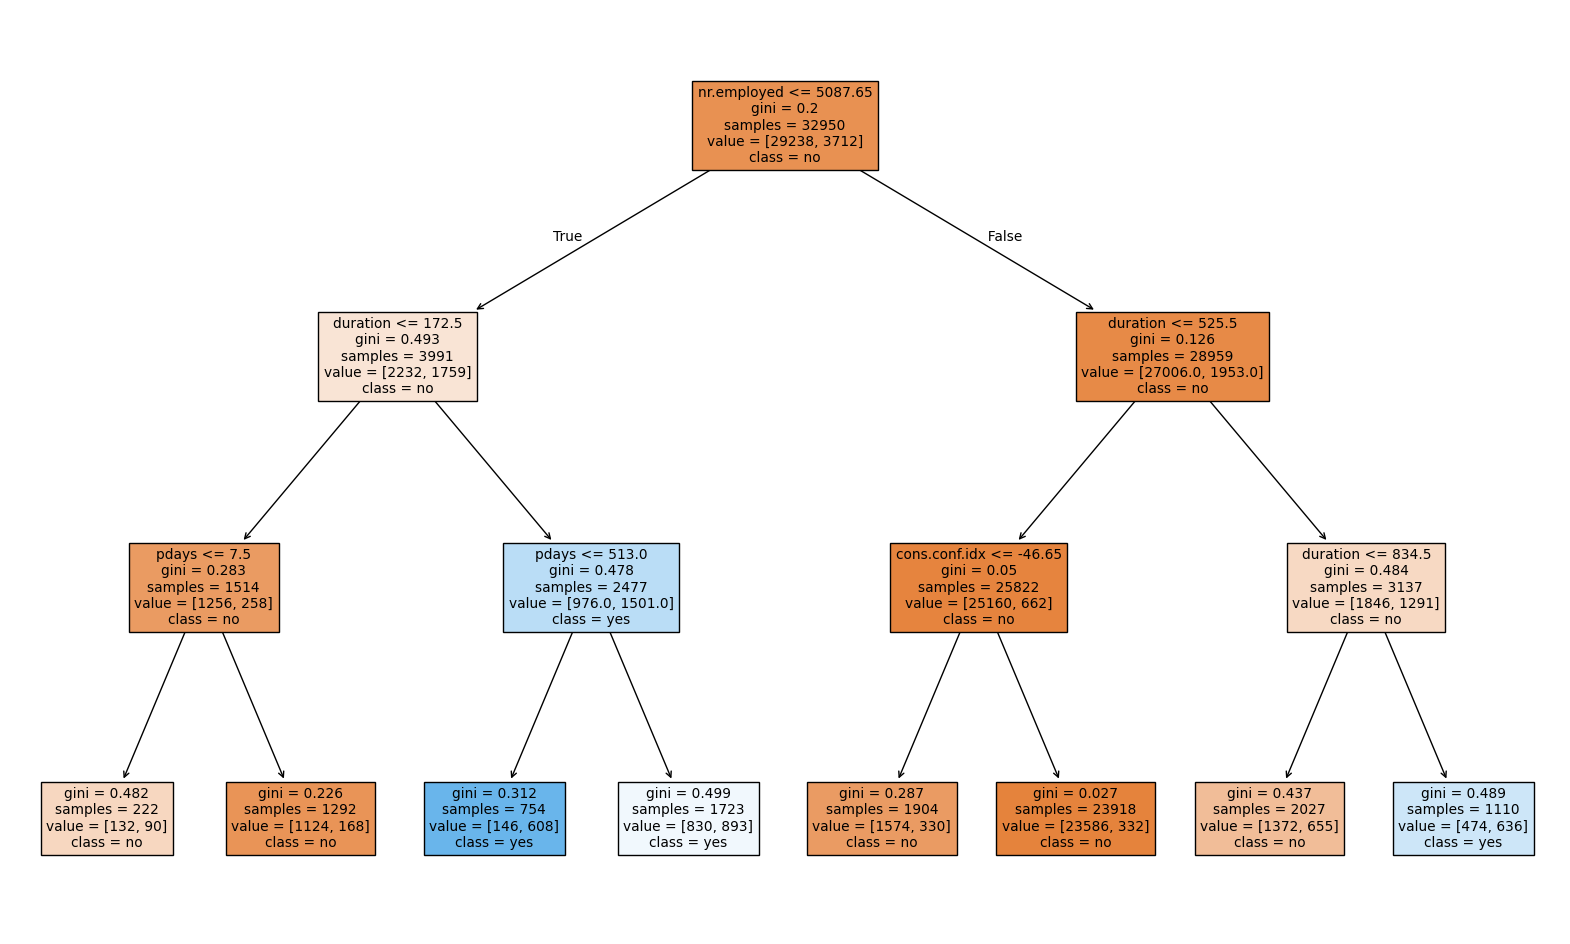

In [21]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Visualization
plt.figure(figsize=(20, 12))
plot_tree(dt, feature_names=X.columns, class_names=['no', 'yes'], filled=True)
plt.show()


Based on the Decision Tree the first stage looks at nr.employed: number of employees - quarterly indicator (numeric) and shows that a number over 5,087.65 leads to higher duration calls. Longer call duration is strongly linked to term deposit subscriptions to a certain point of around 834.5 seconds. A low consumer price index leads to fewer subscriptions. pdays: number of days that passed after the client was last contacted from a previous campaign (numeric; 999 means the client was not previously contacted); values greater than 7.5 lead to more subscriptions. Overall, the biggest driver of sign-ups is the economy; based on the number of employees, having fewer than 5,087 employees drives most subscriptions. 

Follow-up:
The bank should try calling customers to offer subscriptions when the economy is declining, since they seem more likely to sign up. Also, employees should be trained not to call people contacted within the last week and to spend between 172 and 800 seconds per call. 


##### Questions